### Voice Data Set

This database was created to identify a voice as male or female, based upon acoustic properties of the voice and speech. The dataset consists of 3800 recorded voice samples. The voice samples are pre-processed by acoustic analysis in R using the seewave and tuneR packages.

The following acoustic properties of each voice are measured and included within the CSV:

<ul>
<li><strong>meanfreq</strong>: mean frequency (in kHz)</li>
<li><strong>sd</strong>: standard deviation of frequency</li>
<li><strong>median</strong>: median frequency (in kHz)</li>
<li><strong>Q25</strong>: first quantile (in kHz)</li>
<li><strong>Q75</strong>: third quantile (in kHz)</li>
<li><strong>IQR</strong>: interquantile range (in kHz)</li>
<li><strong>skew</strong>: skewness (see note in specprop description)</li>
<li><strong>kurt</strong>: kurtosis (see note in specprop description)</li>
<li><strong>sp.ent</strong>: spectral entropy</li>
<li><strong>sfm</strong>: spectral flatness</li>
<li><strong>mode</strong>: mode frequency</li>
<li><strong>centroid</strong>: frequency centroid (see specprop)</li>
<li><strong>peakf</strong>: peak frequency (frequency with highest energy)</li>
<li><strong>meanfun</strong>: average of fundamental frequency measured across acoustic signal</li>
<li><strong>minfun</strong>: minimum fundamental frequency measured across acoustic signal</li>
<li><strong>maxfun</strong>: maximum fundamental frequency measured across acoustic signal</li>
<li><strong>meandom</strong>: average of dominant frequency measured across acoustic signal</li>
<li><strong>mindom</strong>: minimum of dominant frequency measured across acoustic signal</li>
<li><strong>maxdom</strong>: maximum of dominant frequency measured across acoustic signal</li>
<li><strong>dfrange</strong>: range of dominant frequency measured across acoustic signal</li>
<li><strong>modindx</strong>: modulation index. Calculated as the accumulated absolute difference between adjacent measurements of fundamental frequencies divided by the frequency range</li>
<li><strong>label</strong>: male or female</li>
</ul>

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

#### 2) Data Loading:

In [2]:
df = pd.read_csv('voice-classification.csv')

In [3]:
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [4]:
df.shape

(3168, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
meanfreq,3168.0,0.180907,0.029918,0.039363,0.163662,0.184838,0.199146,0.251124
sd,3168.0,0.057126,0.016652,0.018363,0.041954,0.059155,0.067020,0.115273
median,3168.0,0.185621,0.036360,0.010975,0.169593,0.190032,0.210618,0.261224
Q25,3168.0,0.140456,0.048680,0.000229,0.111087,0.140286,0.175939,0.247347
Q75,3168.0,0.224765,0.023639,0.042946,0.208747,0.225684,0.243660,0.273469
IQR,3168.0,0.084309,0.042783,0.014558,0.042560,0.094280,0.114175,0.252225
skew,3168.0,3.140168,4.240529,0.141735,1.649569,2.197101,2.931694,34.725453
kurt,3168.0,36.568461,134.928661,2.068455,5.669547,8.318463,13.648905,1309.612887
sp.ent,3168.0,0.895127,0.044980,0.738651,0.861811,0.901767,0.928713,0.981997
sfm,3168.0,0.408216,0.177521,0.036876,0.258041,0.396335,0.533676,0.842936


- All features are Numeric and Continuous in nature.
- There are no missing values in dataset.
- Target Variable is 'label' (Categorical).

#### 3) Feature Scaling:
- As all the features are numeric, for simplicity, we will just scale them.

In [7]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), list(df.drop('label', axis= 1))) # Including all the columns except Target
])

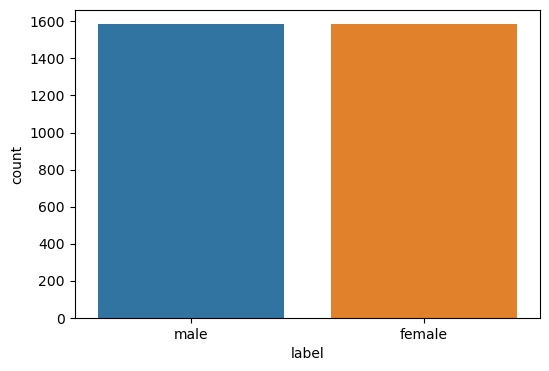

In [8]:
# Target:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'label', hue= 'label')
plt.show()

- We have balanced class distribution in dataset.

In [9]:
# Mapping Classes in Target Variable to Numbers:

df['label'] = df['label'].map({'male': 0, 'female': 1})

In [10]:
df['label'].value_counts()

label
0    1584
1    1584
Name: count, dtype: int64

#### 4) Train Test Split:

In [11]:
X = df.drop('label', axis= 1) #Features
y = df['label'] #Target

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2534, 20)
(634, 20)
(2534,)
(634,)


#### 5) Model building and Evaluation:

In [14]:
model_pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', SVC())
])

In [18]:
param_dict = {'Model__kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
             'Model__C': [0.01, 0.1, 1, 10, 100],
             'Model__degree': [1,2,3],
             'Model__gamma': ['scale', 'auto']
             }

In [19]:
grid_model = GridSearchCV(estimator= model_pipeline,
                         param_grid= param_dict,
                         cv= 5,
                         n_jobs= -1)

In [20]:
# Fitting The Grid Model:
grid_model.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'Model__C': [0.01, 0.1, ...], 'Model__degree': [1, 2, ...], 'Model__gamma': ['scale', 'auto'], 'Model__kernel': ['poly', 'linear', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...)]"


In [ ]:
# Best Estimator and Parameters according to Grid Search:
